In [26]:
import pandas as pd

In [27]:
df = pd.read_csv('data/titanic_v1.csv')

El método .sample(3) extrae 3 filas del DataFrame. La selección (o muestra) la hace de manera aleatoria.

In [28]:
df.sample(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
512,513,1,1,"McGough, Mr. James Robert",male,36.0,0,0,PC 17473,26.2875,E25,S
737,738,1,1,"Lesurer, Mr. Gustave J",male,35.0,0,0,PC 17755,512.3292,B101,C
567,568,0,3,"Palsson, Mrs. Nils (Alma Cornelia Berglund)",female,29.0,0,4,349909,21.0750,NaN,S


In [29]:
print(f"El shape del conjunto de entrenamiento es {df.shape}. {df.shape[0]} filas y {df.shape[1]} columnas.") 

El shape del conjunto de entrenamiento es (891, 12). 891 filas y 12 columnas.


Conjunto de entrenamiento

Veamos con más detalle el conjunto de entrenamiento:

In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


Esto nos permite tener una ayuda visual para identificar columnas problemáticas más fácilmente.

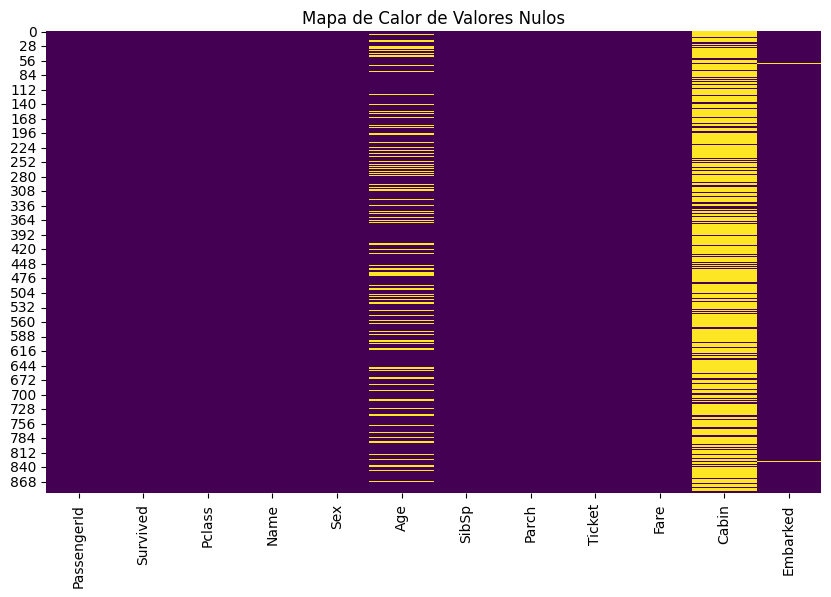

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

# Suponiendo que tu dataframe se llama 'df'
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')

plt.title('Mapa de Calor de Valores Nulos')

# Guardar el gráfico como un archivo PNG
plt.savefig('output.png', format='png')

# Mostrar el gráfico
plt.show()

Pidámosle ahora a ChatGPT que nos muestre los porcentajes de valores nulos de las columnas de nuestro conjunto de datos:

Prompt 💡:

Tengo un DataFrame df. Esribe el código que me muestre el porcentaje de valores faltantes de cada columna del conjunto de datos df. Redondea a 2 decimales. Ordena los valores de mayor a menor.

In [32]:
missing_values_percentage = df.isnull().mean() * 100
missing_values_percentage = missing_values_percentage.round(2).sort_values(ascending=False)
print(missing_values_percentage)

Cabin          77.10
Age            19.87
Embarked        0.22
PassengerId     0.00
Name            0.00
Pclass          0.00
Survived        0.00
Sex             0.00
Parch           0.00
SibSp           0.00
Fare            0.00
Ticket          0.00
dtype: float64


Tengo un DataFrame df. Ayudame a escribir el código en python para mostrar una gráfica de barras usando seaborn, donde muestre el total de valores faltantes en cada columna del conjunto de datos df.

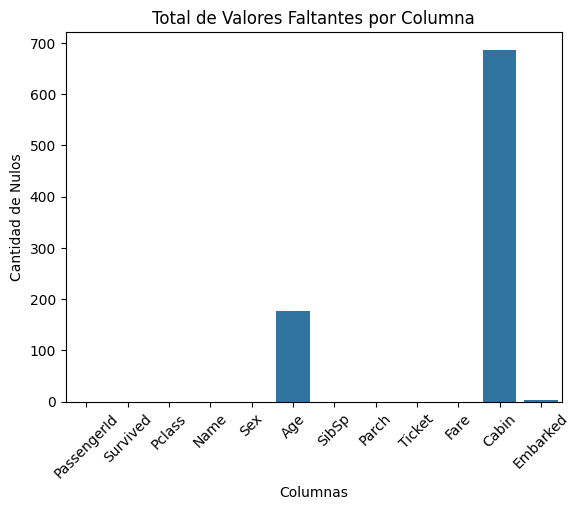

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calcular la suma de nulos por columna
nulos = df.isnull().sum()

# 2. Crear la gráfica de barras
sns.barplot(x=nulos.index, y=nulos.values)

# 3. Personalizar la gráfica (opcional)
plt.title('Total de Valores Faltantes por Columna')
plt.ylabel('Cantidad de Nulos')
plt.xlabel('Columnas')
plt.xticks(rotation=45) # Rota los nombres si son muy largos
plt.show()


Columna Cabin

Dado que no tenemos la gran mayoría de los datos de Cabin nos conviene mejor deshacernos de esta columna. 

In [48]:
df.drop('Cabin', axis = 1, inplace = True)

KeyError: "['Cabin'] not found in axis"

Preguntemos a ChatGPT lo siguiente:

Prompt 💡:

Mi conjunto de datos df tiene el 78.23% de los datos de la columna Cabin en nulo, y 20.57% de la columna Age. He decidido eliminar la columna Cabin, pero no quiero eliminar la columna Age porque será importante para mi modelo. Cuál puede ser una estrategia muy simple para no tener valores en nulo en esta columna sin tener que eliminar las filas que los contienen? Escribe una respuesta corta y el código.

Respuesta 🤖:

Una estrategia simple para manejar los valores nulos en la columna Age sin eliminar las filas que los contienen es imputar los valores faltantes con la media de la columna. Esto permite mantener todas las filas y proporciona una estimación razonable para los valores faltantes.

In [49]:
# Calcular la media de la columna Age
mean_age = df['Age'].mean()

# Imputar los valores nulos con la media
df['Age'].fillna(mean_age, inplace=True)

C:\Users\Israel\AppData\Local\Temp\ipykernel_32704\1483765289.py:5: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Age'].fillna(mean_age, inplace=True)


0      22.000000
1      38.000000
2      26.000000
3      35.000000
4      35.000000
         ...    
886    27.000000
887    19.000000
888    29.699118
889    26.000000
890    32.000000
Name: Age, Length: 891, dtype: float64

Ojo aquí 👀

Este es un excelente ejemplo de cómo no siempre tenemos que confiarnos al 100% de la primera respuesta que nos brinda una IA generativa como ChatGPT. 

De nuestras clases de Probabilidad y Estadística sabemos que la media tiene una pequeña desventaja:

¡La media es sensible a valores atípicos!

En esta misma conversación, pidamos a ChatGPT que reconsidere con este simple prompt:

Prompt 💡:

¿Por qué la media y no la mediana?

Respuesta 🤖:

Elegir entre la media y la mediana para imputar valores faltantes depende de la distribución de los datos en la columna Age.

Media: Es apropiada si la distribución de los datos es simétrica y no contiene valores atípicos (outliers). La media puede ser afectada por valores extremadamente altos o bajos, lo que podría sesgar el valor imputado.

Mediana: Es más robusta frente a valores atípicos y es una mejor opción si la distribución de los datos es asimétrica o contiene outliers. La mediana no se ve afectada por valores extremos, por lo que proporciona una representación más precisa del centro de la distribución en estos casos.

Para una imputación más robusta, es recomendable usar la mediana si la columna Age tiene outliers o una distribución sesgada.

In [50]:
# Calcular la mediana de la columna Age
median_age = df['Age'].median()

# Imputar los valores nulos con la mediana
df['Age'].fillna(median_age, inplace=True)

C:\Users\Israel\AppData\Local\Temp\ipykernel_32704\686027435.py:5: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Age'].fillna(median_age, inplace=True)


0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
886    27.0
887    19.0
888    28.0
889    26.0
890    32.0
Name: Age, Length: 891, dtype: float64

Columna Embarked

¿Qué hay de la columa Embarked?

Recordemos que esta columna contiene el puerto de embarque (C = Cherbourg; Q = Queenstown; S = Southampton). Realmente tenemos muy pocos valores nulos en esta columna (únicamente el 0.22%).

Preguntando a ChatGPT, vemos que una buena estrategia para esta columna es imputar los valores de la moda. 

In [51]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

Si vemos ahora los porcentajes de valores nulos, veremos que ya estamos en ceros:

In [52]:
round(df.isnull().sum().sort_values(ascending = False) / len(df) * 100, 2)

Age            19.87
Survived        0.00
PassengerId     0.00
Pclass          0.00
Name            0.00
Sex             0.00
SibSp           0.00
Parch           0.00
Ticket          0.00
Fare            0.00
Embarked        0.00
dtype: float64

En lugar de ver porcentajes, también podemos ver el total en cada columna:

In [53]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Embarked         0
dtype: int64

Valores duplicados

Verifiquemos rápidamente si nuestros datasets tienen datos duplicados (filas repetidas).

In [54]:
df.duplicated().sum()

np.int64(0)

No tenemos duplicados

Eliminar variables no útiles

In [55]:
df.drop('Name', axis = 1, inplace = True)
df.drop('Ticket', axis = 1, inplace = True)
df.drop('PassengerId', axis = 1, inplace = True)

In [56]:
print(f"Después de limpiar df: {df.shape[0]} filas y {df.shape[1]} columnas.")

Después de limpiar df: 891 filas y 8 columnas.


Guardar datos limpios

Para no haer nuestros notebooks demasiado grandes, haremos un checkpoint aquí. Guarda estos conjuntos de datos en el directorio ./data/.

In [57]:
df.to_csv('./data/titanic_clean.csv', index=False)